In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [ ]:
function mm_field_canal_horizontal(x, y)
    # --- Configuration ---
    x_exit = 100.0      # Where the gradient is highest (Right side)
    width = 50.0        # Total width of the canal (along Y axis)
    center_y = 0.0      # Center of the canal

    sigma_long = 100 # Controls how fast it fades along X (from 100 to -100)
    sigma_trans = 12.5  # Controls the width along Y (approx width/4)

    base = exp((x - x_exit) / sigma_long)

    dist_from_center = y - center_y
    confinement = exp(-(dist_from_center^2) / (2 * sigma_trans^2))

    return base * confinement
end

mm_field_canal_horizontal (generic function with 1 method)

In [203]:
function mm_field_maze(x, y, path_points, exit_index, sigma_long, sigma_trans)
    """
    x, y: Coordinates of the point
    path_points: Vector of tuples [(x1, y1), (x2, y2), ...] defining the maze path
    exit_index: The index in path_points where the gradient is highest (the exit)
    sigma_long: Controls how fast the gradient decays along the path length
    sigma_trans: Controls the width of the "corridor"
    """

    # 1. Find the closest point on the path to (x, y)
    # We calculate the distance to every segment and find the minimum
    min_dist = Inf
    closest_segment_idx = 0
    
    n_segments = length(path_points) - 1
    
    for i in 1:n_segments
        p1 = path_points[i]
        p2 = path_points[i+1]
        
        # Vector from p1 to p2
        dx = p2[1] - p1[1]
        dy = p2[2] - p1[2]
        seg_len_sq = dx*dx + dy*dy
        
        if seg_len_sq == 0
            dist = sqrt((x - p1[1])^2 + (y - p1[2])^2)
        else
            # Project point (x,y) onto the line segment p1-p2
            # t is the parameter along the segment (0 to 1)
            t = max(0.0, min(1.0, ((x - p1[1])*dx + (y - p1[2])*dy) / seg_len_sq))
            
            # Closest point on the segment
            cx = p1[1] + t * dx
            cy = p1[2] + t * dy
            
            # Distance to that closest point
            dist = sqrt((x - cx)^2 + (y - cy)^2)
        end
        
        if dist < min_dist
            min_dist = dist
            closest_segment_idx = i
        end
    end
    
    # 2. Calculate the "Longitudinal" distance along the path
    # We need to know how far along the path the closest point is.
    # We calculate the cumulative length of the path up to the closest segment.
    path_length = 0.0
    for i in 1:(closest_segment_idx - 1)
        p1 = path_points[i]
        p2 = path_points[i+1]
        path_length += sqrt((p2[1]-p1[1])^2 + (p2[2]-p1[2])^2)
    end
    
    # Add the distance along the current segment to the closest point
    if closest_segment_idx > 0 && closest_segment_idx < length(path_points)
        p1 = path_points[closest_segment_idx]
        p2 = path_points[closest_segment_idx+1]
        dx = p2[1] - p1[1]
        dy = p2[2] - p1[2]
        # Calculate distance from p1 to the closest point (cx, cy)
        # We already have the projection parameter 't' from the loop above, 
        # but we need to re-calculate it or store it. 
        # Simpler: just use the distance from p1 to the closest point on the segment
        # We can approximate by using the distance to the segment start + the projected distance
        # Let's re-calculate t for clarity here
        seg_len_sq = dx*dx + dy*dy
        t = ((x - p1[1])*dx + (y - p1[2])*dy) / seg_len_sq
        t = max(0.0, min(1.0, t))
        proj_dist = sqrt((p1[1] + t*dx - p1[1])^2 + (p1[2] + t*dy - p1[2])^2)
        path_length += proj_dist
    end

    # 3. Calculate the total length of the entire path
    total_path_len = 0.0
    for i in 1:(length(path_points)-1)
        p1 = path_points[i]
        p2 = path_points[i+1]
        total_path_len += sqrt((p2[1]-p1[1])^2 + (p2[2]-p1[2])^2)
    end

    # 4. Calculate the distance to the "Exit" point along the path
    # If the exit is the last point, we just use total_path_len
    # We assume the exit is at the end of the path for this example
    exit_dist_along_path = total_path_len - path_length
    
    # 5. Combine into Gradient
    # Transverse: Gaussian decay based on distance from the line
    confinement = exp(-(min_dist^2) / (2 * sigma_trans^2))
    
    # Longitudinal: Exponential decay based on distance from the exit
    # If exit_dist_along_path is 0 (at exit), value is 1.0
    # If far from exit, value drops
    base = exp(-exit_dist_along_path / sigma_long)
    
    return base * confinement
end

mm_field_maze (generic function with 1 method)

In [218]:
function triangular_gradient(x, y)
    x_min = -100.0
    x_max = 100.0
    center_y = 0.0
    width = 50.0

    # Linear gradient in x
    base = clamp((x - x_min) / (x_max - x_min), 0.0, 1.0)

    # Triangular confinement in y
    dist = abs(y - center_y)
    confinement = max(0.0, 1.0 - dist/(width/2))

    return base * confinement
end

triangular_gradient (generic function with 1 method)

In [48]:
function mm_field_square(x, y, x_exit, y_center, width, σ)
    # Longitudinal gradient
    base = exp((x - x_exit)/σ)

    # Square Confinement
    dist = abs(y - y_center(x))
    half_width = width / 2

    # If inside the box, value is 1. If outside, 0.
    confinement = (dist < half_width) ? 1.0 : 0.0

    return base * confinement
end

mm_field_square (generic function with 1 method)

In [314]:
function in_triangle(x, y, x0, y0, size)
    # Simple isosceles triangle pointing right
    # (x0, y0) = left base center

    dx = x - x0
    dy = y - y0

    if dx < 0 || dx > size
        return false
    end

    half_width = (size - dx) * 0.5
    return abs(dy) < half_width
end

in_triangle (generic function with 1 method)

In [321]:
function in_ratchet(x, y)
    spacing = 60.0
    size = 125

    for i in 0:4
        x0 = i * spacing
        if in_triangle(x, y, x0 , 0, size)
            return true
        end
    end

    return false
end

in_ratchet (generic function with 1 method)

In [293]:
function in_triangle_1(x,y)
    height = 125
    y_1 = -50 + height
    base = height/2
    alpha = asin(base/height) 
    c = cos(alpha) * y
    x0 = sin(alpha) * c
    if x < (-x0) || x > x0 || y < -50 || y > y_1
        return false
    else 
        return true
    end
end
    

in_triangle_1 (generic function with 1 method)

In [324]:
if !in_ratchet(50,0)
    println("out")
end

In [186]:
is_allowed(x, y) = abs(y - 0) < width/2

is_allowed (generic function with 1 method)

In [298]:
fixed_source = ABM(2,

agent = Dict(
    :vx => Float64,
    :vy => Float64,
    :v => Float64,
    :theta => Float64,
    :d => Float64,
    :l => Float64,
    :m => Float64,
    :fx => Float64,
    :fy => Float64,
    :W => Float64,
    :pressure => Float64,
    :active => Bool,

    :isSource => Bool,
    :S => Float64,

    :methyl => Float64,
    :Yp => Float64,
    :G => Float64,
    :λ => Float64,
    :P => Float64,
    :M => Float64,
    :F => Float64,
    :A => Float64
),

model = Dict(

    :Dr_run => Float64,

    :ε0 => Float64,
    :ε1 => Float64,
    :ε2 => Float64,
    :ε3 => Float64,
    :K => Float64,
    :Nrec => Float64,
    :Ki => Float64,
    :Ka => Float64,
    :τm => Float64,
    :α => Float64,
    :ωFrec => Float64,
    :Ky => Float64,
    :Z => Float64,
    :Kz => Float64,
    :Yy => Float64,

    :DMedium => Float64,
    :delta => Float64,

    :sigma => Float64,
    :R_source => Float64
),

agentODE = quote  


    # mm = mm_field_canal_horizontal(x, y)
    mm = 0

    M = mm

    F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka))

    F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)

    mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (-ε1)

    A = 1 / (1 + exp(F))    

    Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

    G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))

    dt(x) = vx
    dt(y) = vy  

    dt(methyl) = -(1 / τm) * (methyl - mx)

end,

agentRule = quote

    v_run = v
    v_tumble = 0.25 

    speed = active ? v_run : v_tumble

    Dr_tumble = 6.2      
    Dr_total = active ? Dr_run : Dr_tumble

    if active 
        λ = ωFrec * exp(-G)
        P = 1 - exp(-λ * dt)
    else
        λ = ωFrec * exp(G)
        P = 1 - exp(-λ * dt)
    end


    if active 
        λrt = ωFrec * exp(-G)
        P_rt = 1 - exp(-λrt * dt)

        if rand() < P_rt
            active = false
            vx = speed
            vy = speed
            theta += sqrt(2 * Dr_total * dt) * randn()
        else
            active = true
            vx = speed * cos(theta)
            vy = speed * sin(theta)
            theta += sqrt(2 * Dr_total * dt) * randn()
        end

    else
        λtr = ωFrec * exp(G)
        P_tr = 1 - exp(-λtr * dt)

        if rand() < P_tr
            active = true
            vx = speed * cos(theta)
            vy = speed * sin(theta)
            theta += sqrt(2 * Dr_total * dt) * randn()
        else
            active = false
            vx = speed
            vy = speed
            theta += sqrt(2 * Dr_total * dt) * randn()
        end
    end
    
    if !in_triangle_1(x, y)
        theta = 2*pi - theta

    end

    xmin, xmax = simBox[1,1], simBox[1,2]
    ymin, ymax = simBox[2,1], simBox[2,2]

        # X walls
    if x < xmin
        x = xmin
        theta = pi - theta
    elseif x > xmax
        x = xmax
        theta = pi - theta
    end

        # Y walls
    if y < ymin
        y = ymin
        theta = 2*pi - theta
    elseif y > ymax
        y = ymax
        theta = 2*pi - theta
    end

end,



agentAlg = CBMIntegrators.Heun(),
mediumAlg = DifferentialEquations.Euler(),
neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 10)

)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if ac

In [299]:
com = Community(
    fixed_source,
    N=20,
    dt=0.01,
    simBox = [-100 100.0; -100 100.0],
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 10
com.delta = 0.01

com.x = 0.1
com.y = 0.1
# com.x = 2.5*sqrt(com.DMedium/com.delta)
# com.y = 2.5*sqrt(com.DMedium/com.delta)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 



20-element Vector{Bool}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

In [300]:
outfile = "triangle_test.jld2"
steps = 20000

loadToPlatform!(com, preallocateAgents=20)
# com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)

    end
end


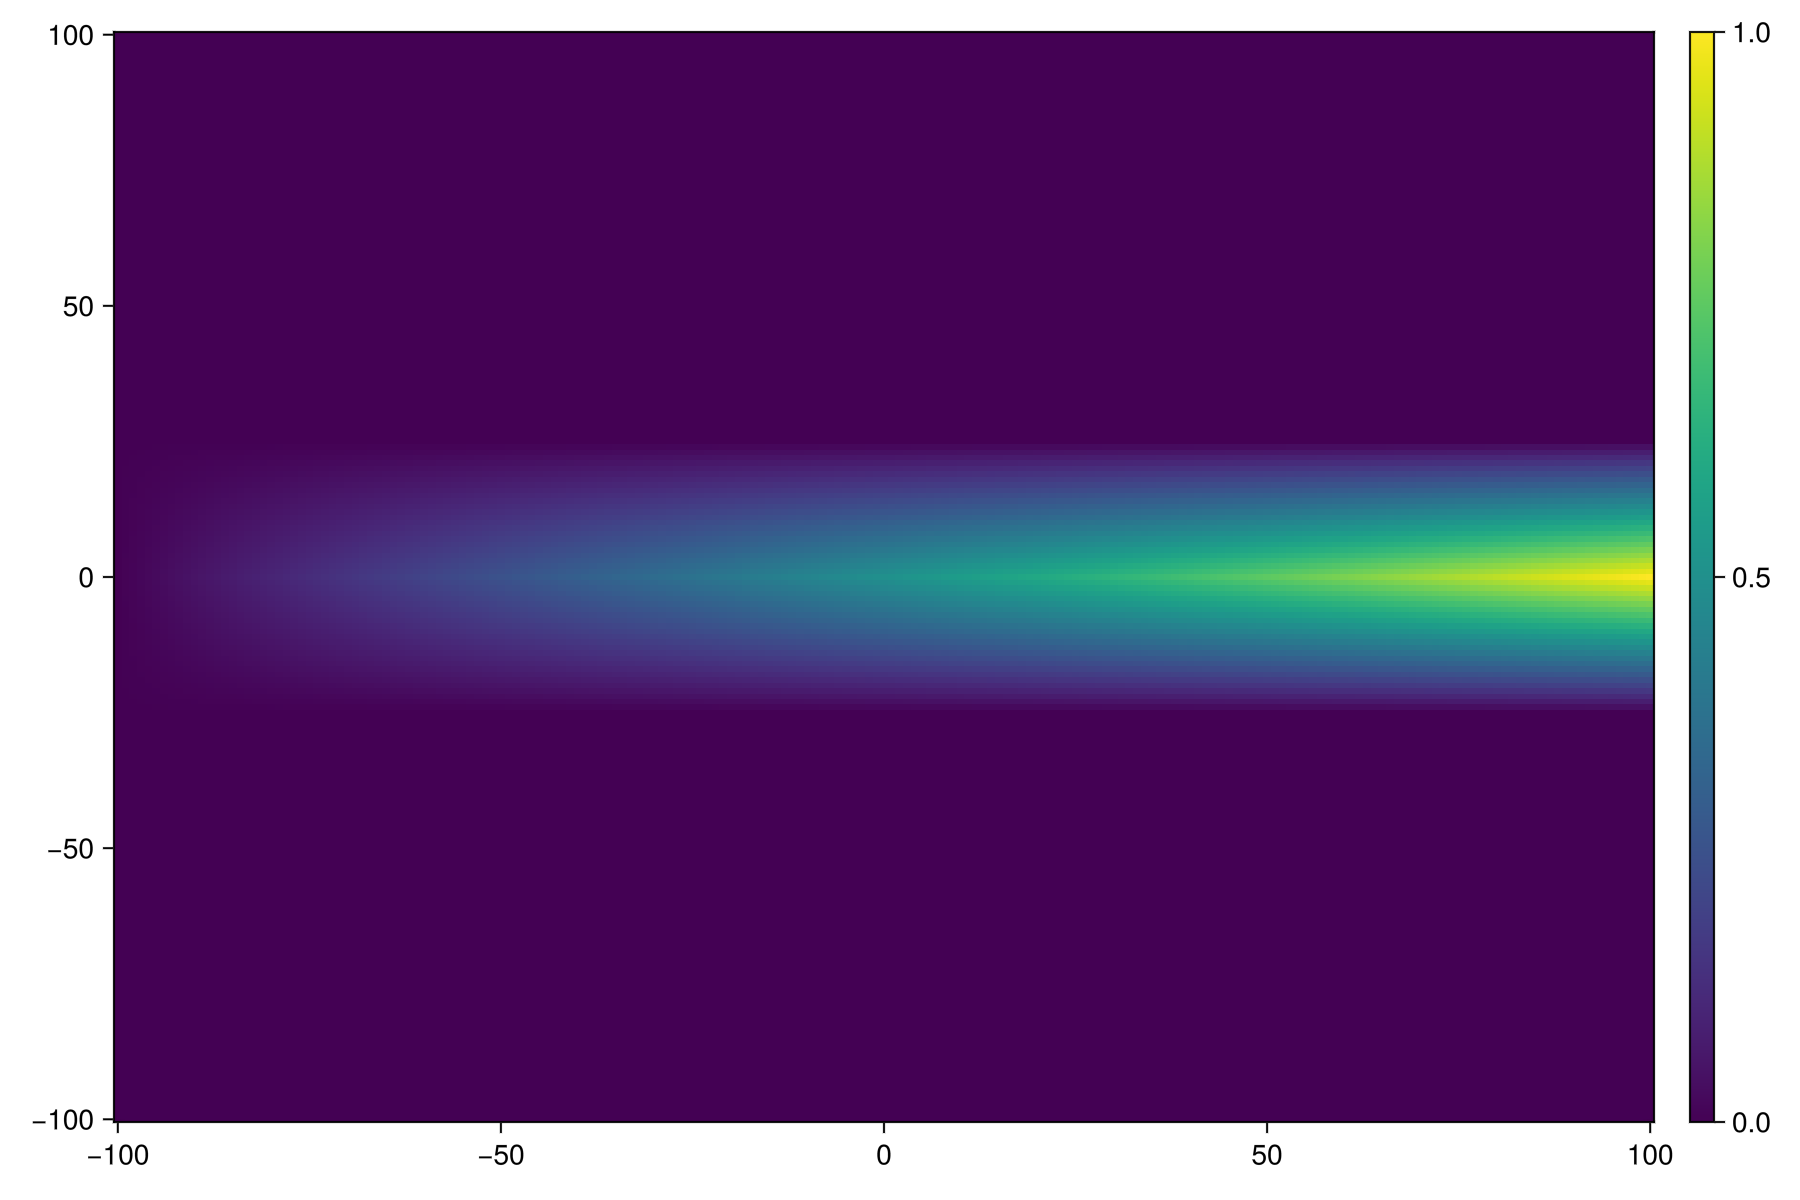

In [222]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1])

xs = -100:1:100
ys = -100:1:100
# width = 1000

# y_center(x) = 50*x
# x_exit = 0.1
Z = [triangular_gradient(x, y) for  x in xs, y in ys]
hm = heatmap!(ax, ys, xs, Z)
Colorbar(fig[1,2], hm)
fig


In [325]:
function in_triangle(x, y, x0, y0, size)
    dx = x - x0
    dy = y - y0

    if dx < 0 || dx > size
        return false
    end

    half_width = (size - dx) * 0.5
    return abs(dy) < half_width
end

# Grid
xs = range(-100, 100, length=200)
ys = range(-100, 100, length=200)

# Evaluate mask
Z = [in_triangle(x, y, -50, 0, 125.0) ? 1.0 : 0.0 for y in ys, x in xs]

# Plot
fig = Figure()
ax = Axis(fig[1, 1], title="Single Triangle")
x_1 = fill(0.0, length(ys))

heatmap!(ax, xs, ys, Z)
lines!(ax, x_1, ys, color = :red)
# contour!(ax, xs, ys, Z, levels=[0.5])

fig

In [217]:
# 1. Define the Path (The "Open Square")
# Points: Start -> Right -> Up -> Left -> End (Exit)
# This creates a U-shape
path = [
    (-50, -50),  # Start (Bottom Left)
    (50, -50),   # Bottom Right
    (50, 50),    # Top Right
    (-50, 50)    # End/Exit (Top Left)
]

# 2. Define Parameters
sigma_long = 30.0   # How fast the gradient fades along the path
sigma_trans = 8.0   # Width of the corridor

# 3. Create the Grid
x_vals = -60:1.0:60
y_vals = -60:1.0:60
Z = zeros(length(y_vals), length(x_vals))

for (i, y) in enumerate(y_vals)
    for (j, x) in enumerate(x_vals)
        # Calculate gradient for every point
        Z[i, j] = mm_field_maze(x, y, path, length(path), sigma_long, sigma_trans)
    end
end
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1])
# 4. Plot
heatmap!(ax, x_vals, y_vals, Z, 
     colormap=:viridis)

# Optional: Overlay the path to verify
lines!(ax, [p[1] for p in path], [p[2] for p in path], 
       color=:red, 
       linestyle=:dash, 
       linewidth=2, 
       label="Path")
fig

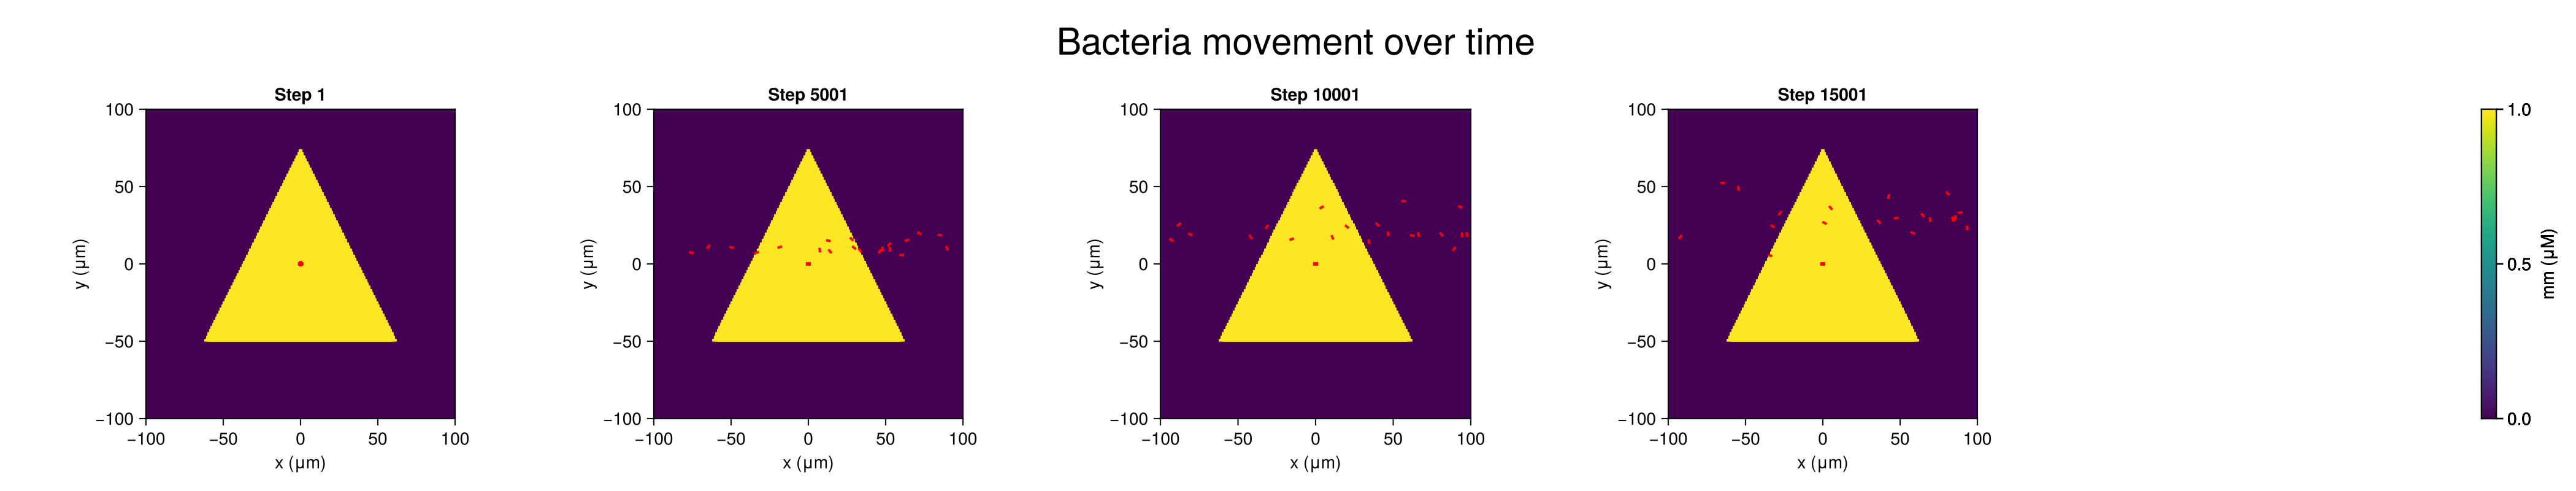

GLMakie.Screen(...)

In [301]:
fig2 = Figure(size=(2100,400))

model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]

# xs = -100:1:100
# ys = -100:1:100

# Z = [mm_field_canal_horizontal(x, y) for  x in xs, y in ys]
xs = range(-100, 100, length=200)
ys = range(-100, 100, length=200)

# Evaluate mask
Z = [in_triangle(x, y, -50, 0, 125.0) ? 1.0 : 0.0 for y in ys, x in xs]

xline = xs
upper = fill(25, length(xs))
lower = fill(-25, length(xs))

jldopen("triangle_test.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 20)
        y = Vector{Float64}(undef, 20)

        ax = Axis(fig2[1, 1*j-1], aspect=1, title="Step $step",  xlabel="x (μm)", ylabel="y (μm)")

        g = file[@sprintf("step_%06d", step)]

        hm = heatmap!(ax, xs, ys, Z)
        Colorbar(fig2[1, 5], hm, label="mm (μM)")


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end
        # lines!(ax, xline, upper, color=:white)
        # lines!(ax, xline, lower, color=:white)

        xlims!(ax, -100, 100)
        ylims!(ax, -100, 100)

    end
end

supertitle  = Label(fig2[0, :], "Bacteria movement over time", fontsize = 30)

display(fig2)

In [302]:
data = Dict{Int, Any}()
steps = 20000
jldopen("triangle_test.jld2", "r") do file
    for step in 1:steps
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "x" => copy(key["x"]),
            "y" => copy(key["y"]),
            "theta" => copy(key["theta"])
            # "l" => copy(key["l"]),
            # "mm_grid" => copy(key["mm_grid"])
        )
    end
end

# Setup plot
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], aspect=1, title="Step 1", xlabel="x (μm)", ylabel="y (μm)")

# Initialize scatter and lines
scatter_plt = scatter!(ax, Float64[], Float64[], color=:red, markersize=5, label="Bacteria")
# source_plt = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")

# Slider
slider = Slider(fig[2, 1:2], range=1:steps, startvalue=1, update_while_dragging = true)
Label(fig[2, 3], "Step: ", fontsize=14)

# Update function
function update_plot(step)
    empty!(ax)

    g = data[step]
    # mm_grid = g["mm_grid"]
    # mm = reshape(mm_grid, (200,200))

    hm = heatmap!(ax, xs, ys, Z)

    # Colorbar(fig[1, 2], hm, label="mm (μM)")

    
    x = g["x"]
    y = g["y"]
    theta = g["theta"]
    l = 3

    # Update scatter
    scatter_plt[1] = x
    scatter_plt[2] = y

    # Compute rod endpoints
    xs1 = x .+ l ./ 2 .* cos.(theta)
    ys1 = y .+ l ./ 2 .* sin.(theta)
    xs2 = x .- l ./ 2 .* cos.(theta)
    ys2 = y .- l ./ 2 .* sin.(theta)
    
    for i in 1:length(x)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
    end

    # Update title
    ax.title = "Step $step"

    # Redraw
    # autolimits!(ax)
    xlims!(ax, -100, 100)
    ylims!(ax, -100, 100)

end

# Connect slider to update
on(slider.value) do val
    update_plot(Int(val))
end

# Initialize
update_plot(1)

# Display
# display(fig)

GLMakie.activate!()
display(fig)

GLMakie.Screen(...)